# 📊 Exploratory Data Analysis (EDA)
**Dự án:** Phân tích dữ liệu bán hàng Việt Nam 2024

**Mục tiêu:**
- Hiểu cấu trúc dữ liệu
- Tìm xu hướng doanh thu theo thời gian
- So sánh hiệu suất theo thành phố và danh mục sản phẩm
- Trực quan hóa kết quả

## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Import thư viện thành công!')

✅ Import thư viện thành công!


## 2. Tải & Xem dữ liệu

In [2]:
df = pd.read_csv('../data/raw/sales_data.csv')
print(f'📦 Shape: {df.shape[0]} dòng x {df.shape[1]} cột')
df.head(10)

📦 Shape: 500 dòng x 9 cột


,order_id,month,city,category,quantity,unit_price,discount,customer_age,rating
0,ORD0001,2024-11,Hanoi,Electronics,9,527.54,5,65,1.40
1,ORD0002,2024-12,Hue,Electronics,19,872.75,0,23,1.90
2,ORD0003,2024-09,Hue,Electronics,18,437.73,20,44,1.90
3,ORD0004,2024-10,Da Nang,Electronics,6,1411.37,10,35,1.60
4,ORD0005,2024-06,Hanoi,Electronics,13,238.60,10,56,2.10
5,ORD0006,2024-01,Can Tho,Sports,4,1947.58,15,23,3.20
6,ORD0007,2024-11,Hue,Food,19,424.96,0,20,3.60
7,ORD0008,2024-05,Hanoi,Clothing,4,791.25,15,58,4.30
8,ORD0009,2024-03,Da Nang,Food,7,1356.84,0,56,3.50
9,ORD0010,2024-09,HCMC,Clothing,15,789.94,20,32,3.70


In [3]:
# Thông tin tổng quan
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   order_id      500 non-null    str    
 1   month         500 non-null    str    
 2   city          500 non-null    str    
 3   category      500 non-null    str    
 4   quantity      500 non-null    int64  
 5   unit_price    500 non-null    float64
 6   discount      500 non-null    int64  
 7   customer_age  500 non-null    int64  
 8   rating        500 non-null    float64
dtypes: float64(2), int64(3), str(4)
memory usage: 35.3 KB


In [4]:
# Thống kê mô tả
df.describe().round(2)

,quantity,unit_price,discount,customer_age,rating
count,500.00,500.00,500.00,500.00,500.00
mean,11.08,966.81,9.97,40.32,2.99
std,5.86,573.51,6.98,13.25,1.12
min,1.00,55.53,0.00,18.00,1.00
25%,6.00,467.94,5.00,29.00,2.00
50%,11.00,900.79,10.00,40.00,3.00
75%,16.00,1459.15,15.00,51.00,3.90
max,20.00,1999.21,20.00,65.00,5.00


## 3. Làm sạch dữ liệu

In [5]:
# Kiểm tra giá trị null
print('🔍 Giá trị null theo cột:')
print(df.isnull().sum())

# Kiểm tra duplicate
print(f'\n🔁 Số dòng trùng lặp: {df.duplicated().sum()}')

🔍 Giá trị null theo cột:
order_id        0
month           0
city            0
category        0
quantity        0
unit_price      0
discount        0
customer_age    0
rating          0
dtype: int64

🔁 Số dòng trùng lặp: 0


In [6]:
# Tính revenue (doanh thu) sau discount
df['revenue'] = df['quantity'] * df['unit_price'] * (1 - df['discount'] / 100)
df['revenue'] = df['revenue'].round(2)

# Chuyển month sang datetime để sort đúng thứ tự
df['month_dt'] = pd.to_datetime(df['month'])

print('✅ Đã tạo cột revenue và month_dt')
df[['order_id', 'quantity', 'unit_price', 'discount', 'revenue']].head()

✅ Đã tạo cột revenue và month_dt


,order_id,quantity,unit_price,discount,revenue
0,ORD0001,9,527.54,5,4510.47
1,ORD0002,19,872.75,0,16582.25
2,ORD0003,18,437.73,20,6303.31
3,ORD0004,6,1411.37,10,7621.40
4,ORD0005,13,238.60,10,2791.62


In [7]:
# Lưu dữ liệu đã xử lý
df.to_csv('../data/processed/sales_clean.csv', index=False)
print('💾 Đã lưu vào data/processed/sales_clean.csv')

💾 Đã lưu vào data/processed/sales_clean.csv


## 4. Phân tích doanh thu theo tháng

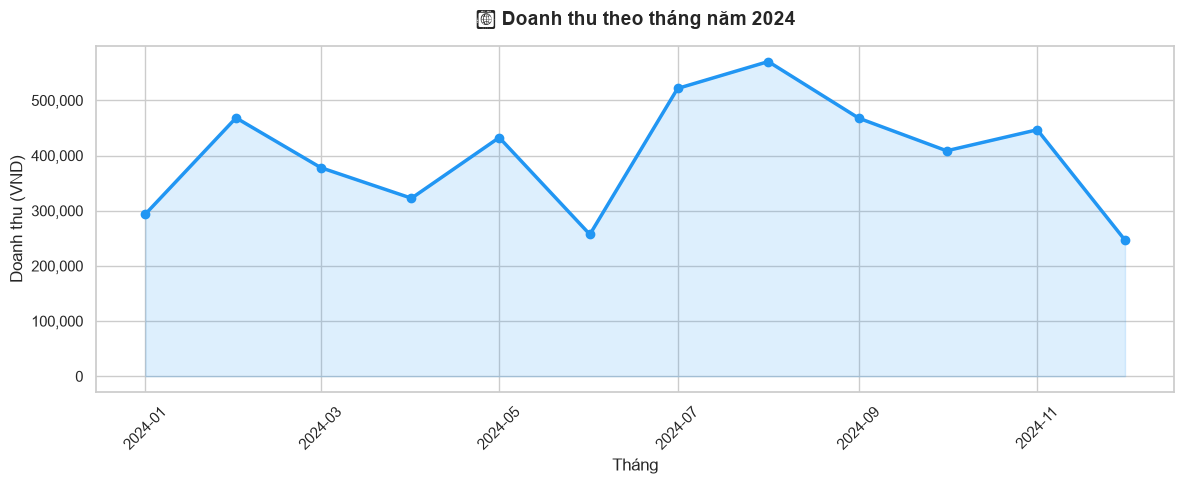

💾 Đã lưu biểu đồ vào outputs/


In [8]:
monthly = df.groupby('month_dt')['revenue'].sum().reset_index()
monthly.columns = ['month', 'total_revenue']
monthly = monthly.sort_values('month')

fig, ax = plt.subplots()
ax.plot(monthly['month'], monthly['total_revenue'], marker='o', linewidth=2.5, color='#2196F3')
ax.fill_between(monthly['month'], monthly['total_revenue'], alpha=0.15, color='#2196F3')
ax.set_title('📈 Doanh thu theo tháng năm 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tháng')
ax.set_ylabel('Doanh thu (VND)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../outputs/01_monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Đã lưu biểu đồ vào outputs/')

## 5. Doanh thu theo thành phố

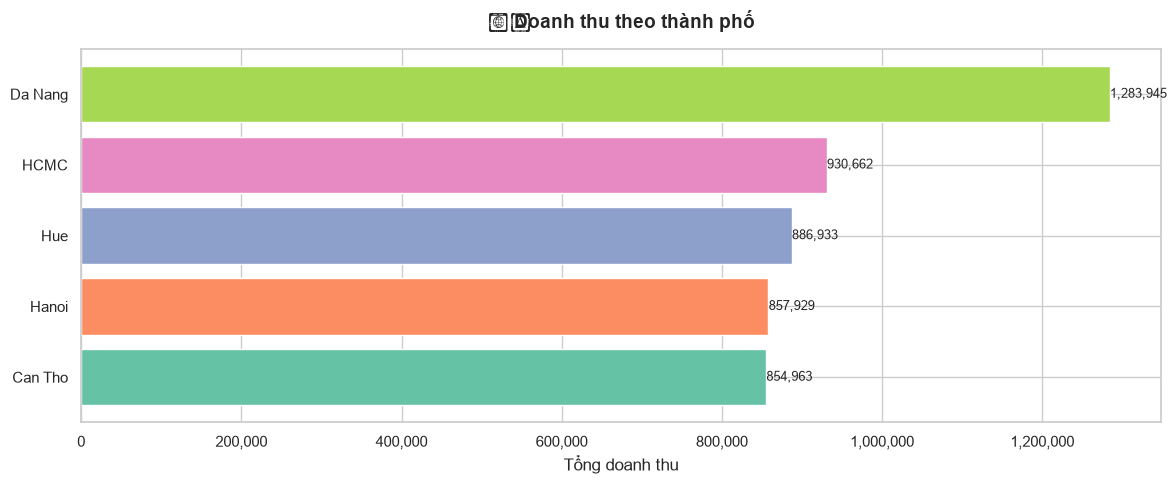

In [9]:
city_rev = df.groupby('city')['revenue'].sum().sort_values(ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(city_rev.index, city_rev.values, color=sns.color_palette('Set2', len(city_rev)))

for bar, val in zip(bars, city_rev.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_title('🏙️ Doanh thu theo thành phố', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Tổng doanh thu')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('../outputs/02_city_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Doanh thu theo danh mục sản phẩm

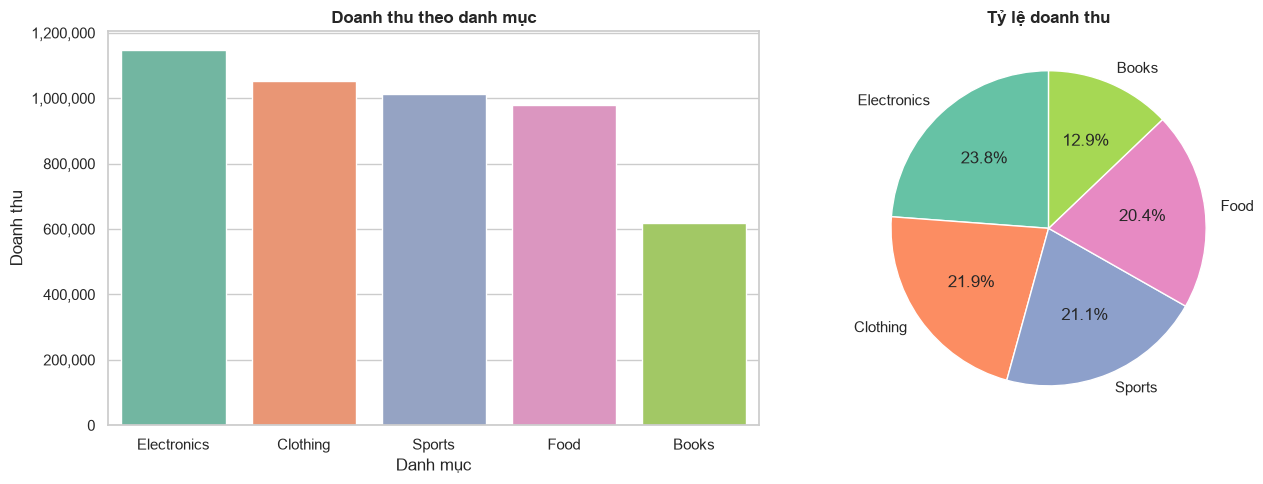

In [10]:
cat_rev = df.groupby('category')['revenue'].sum().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=cat_rev.index, y=cat_rev.values, palette='Set2', ax=ax1)
ax1.set_title('Doanh thu theo danh mục', fontweight='bold')
ax1.set_xlabel('Danh mục')
ax1.set_ylabel('Doanh thu')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Pie chart
ax2.pie(cat_rev.values, labels=cat_rev.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(cat_rev)), startangle=90)
ax2.set_title('Tỷ lệ doanh thu', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/03_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Phân tích rating khách hàng

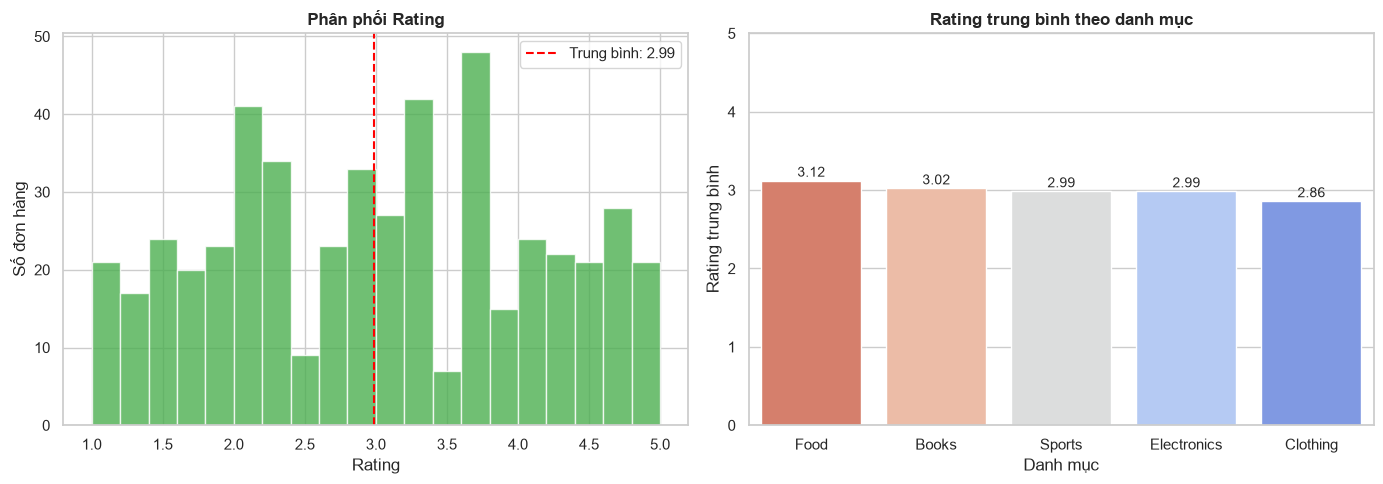

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Phân phối rating
ax1.hist(df['rating'], bins=20, color='#4CAF50', edgecolor='white', alpha=0.8)
ax1.axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Trung bình: {df["rating"].mean():.2f}')
ax1.set_title('Phân phối Rating', fontweight='bold')
ax1.set_xlabel('Rating')
ax1.set_ylabel('Số đơn hàng')
ax1.legend()

# Rating trung bình theo danh mục
cat_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)
sns.barplot(x=cat_rating.index, y=cat_rating.values, palette='coolwarm_r', ax=ax2)
ax2.set_title('Rating trung bình theo danh mục', fontweight='bold')
ax2.set_xlabel('Danh mục')
ax2.set_ylabel('Rating trung bình')
ax2.set_ylim(0, 5)
for i, v in enumerate(cat_rating.values):
    ax2.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/04_rating_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Heatmap: Doanh thu theo thành phố & danh mục

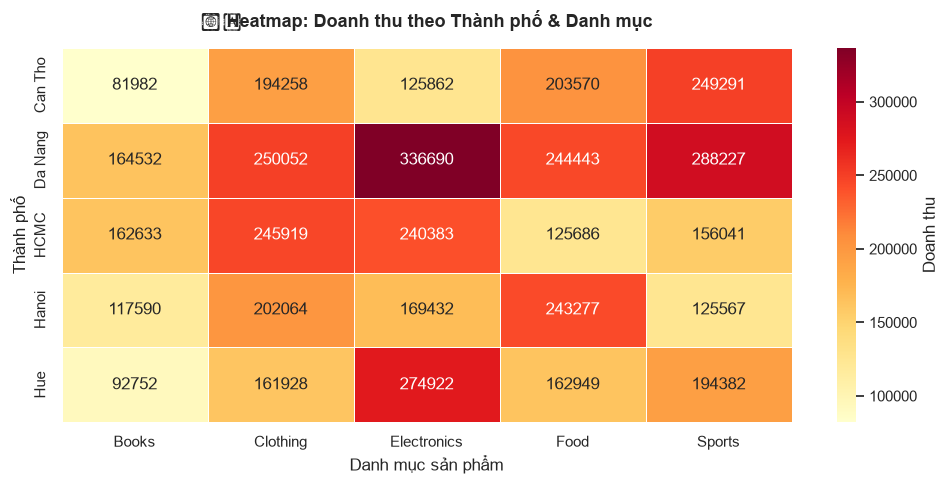

In [12]:
pivot = df.pivot_table(values='revenue', index='city', columns='category', aggfunc='sum')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Doanh thu'})
ax.set_title('🗺️ Heatmap: Doanh thu theo Thành phố & Danh mục', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Danh mục sản phẩm')
ax.set_ylabel('Thành phố')
plt.tight_layout()
plt.savefig('../outputs/05_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Tổng kết (Key Insights)

In [13]:
print('=' * 50)
print('📊 TỔNG KẾT KẾT QUẢ PHÂN TÍCH')
print('=' * 50)
print(f'\n📦 Tổng số đơn hàng    : {len(df):,}')
print(f'💰 Tổng doanh thu      : {df["revenue"].sum():,.0f} VND')
print(f'📈 Doanh thu TB/đơn    : {df["revenue"].mean():,.0f} VND')
print(f'⭐ Rating trung bình   : {df["rating"].mean():.2f}/5.0')
print(f'\n🏙️  Thành phố dẫn đầu  : {city_rev.idxmax()} ({city_rev.max():,.0f})')
print(f'🏆 Danh mục dẫn đầu   : {cat_rev.idxmax()} ({cat_rev.max():,.0f})')
print(f'\n✅ Đã lưu 5 biểu đồ vào thư mục outputs/')

📊 TỔNG KẾT KẾT QUẢ PHÂN TÍCH

📦 Tổng số đơn hàng    : 500
💰 Tổng doanh thu      : 4,814,432 VND
📈 Doanh thu TB/đơn    : 9,629 VND
⭐ Rating trung bình   : 2.99/5.0

🏙️  Thành phố dẫn đầu  : Da Nang (1,283,945)
🏆 Danh mục dẫn đầu   : Electronics (1,147,289)

✅ Đã lưu 5 biểu đồ vào thư mục outputs/
